Connecting to NOAA climate server...
Extracting equatorial Pacific region...
Data processed successfully! Plotting climate anomaly time-series...


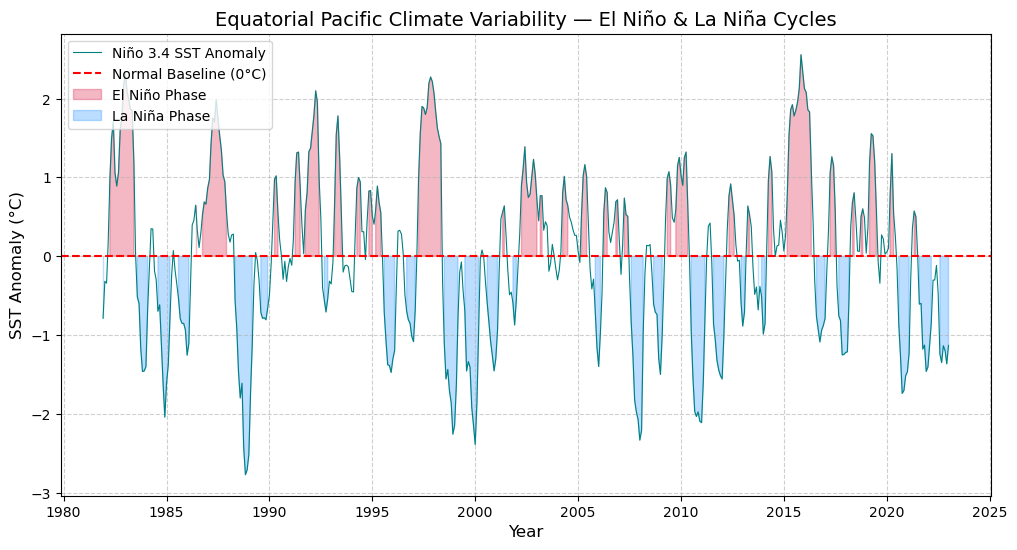

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# 1. Connect to NOAA's stable monthly OISST dataset via OPeNDAP
url = "https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.oisst.v2/sst.mnmean.nc"
print("Connecting to NOAA climate server...")
ds = xr.open_dataset(url)

# Sort latitude coordinates so slicing works properly from South to North
ds = ds.sortby('lat')

# 2. Extract the Niño 3.4 region in the Equatorial Pacific (5°S to 5°N, 190°E to 240°E)
print("Extracting equatorial Pacific region...")
niño34 = ds.sst.sel(
    lat=slice(-5, 5),
    lon=slice(190, 240)
)

# 3. Compute spatial mean and load data into memory
print("Downloading and processing spatial averages...")
niño34_mean = niño34.mean(dim=['lat', 'lon'], skipna=True).load()

# 4. Convert absolute SST into an Anomaly by subtracting the long-term mean over time
climatology_mean = niño34_mean.mean(dim='time')
niño34_anomaly = niño34_mean - climatology_mean

print("Data processed successfully! Plotting climate anomaly time-series...")

# 5. Plot the multi-decadal temperature anomaly variability
plt.figure(figsize=(12, 6))
plt.plot(niño34_anomaly.time, niño34_anomaly, color='teal', linewidth=0.8, label='Niño 3.4 SST Anomaly')

# Add a reference line at 0 (the normal historical baseline)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Normal Baseline (0°C)')

# Shade El Niño (warm phases > +0.5°C) and La Niña (cold phases < -0.5°C)
plt.fill_between(niño34_anomaly.time, niño34_anomaly, 0, where=(niño34_anomaly >= 0.5), color='crimson', alpha=0.3, label='El Niño Phase')
plt.fill_between(niño34_anomaly.time, niño34_anomaly, 0, where=(niño34_anomaly <= -0.5), color='dodgerblue', alpha=0.3, label='La Niña Phase')

plt.xlabel("Year", fontsize=12)
plt.ylabel("SST Anomaly (°C)", fontsize=12)
plt.title("Equatorial Pacific Climate Variability — El Niño & La Niña Cycles", fontsize=14)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)

# 6. Save the output figure
plt.savefig("../figures/climate_variability_timeseries.png", dpi=300, bbox_inches='tight')
plt.show()